In [56]:
# Manipulação dos Dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de regressão
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# Métricas de regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

#Árvore de Decisão
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.tree import export_text

Passo 1: Obtenção dos Dados

In [20]:
# URL do dataset
GITHUB_URL = (
    "https://raw.githubusercontent.com/Finance-781/FinML/master/"
    "Lecture%202%20-%20End-to-End%20ML%20Project%20/Practice/datasets/"
    "sydney_airbnb.csv"
)

df = pd.read_csv(GITHUB_URL)
print("O tamanho do dataset é:", df.shape)
df.head()


O tamanho do dataset é: (27070, 84)


/tmp/ipykernel_788/3512607590.py:8: DtypeWarning: Columns (36,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(GITHUB_URL)


,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,11156,https://www.airbnb.com/rooms/11156,An Oasis in the City,Very central to the city which can be reached ...,Potts Pt. is a vibrant and popular inner-city...,Very central to the city which can be reached ...,"It is very close to everything and everywhere,...","$150.00 key security deposit, refundable on re...",It is 7 minutes walk to the Kings Cross.train ...,Kitchen & laundry facilities. Shared bathroom.,...,10.0,10.0,10.0,9.0,f,moderate,f,f,1,1.69
1,12351,https://www.airbnb.com/rooms/12351,Sydney City & Harbour at the door,Come stay with Vinh & Stuart (Awarded as one o...,"We're pretty relaxed hosts, and we fully appre...",Come stay with Vinh & Stuart (Awarded as one o...,"Pyrmont is an inner-city village of Sydney, on...",We've a few reasons for the 6.00pm arrival tim...,Our home is centrally located and an easy walk...,We look forward to welcoming you just as we wo...,...,10.0,10.0,10.0,10.0,f,strict_14_with_grace_period,t,t,2,4.83
2,14250,https://www.airbnb.com/rooms/14250,Manly Harbour House,"Beautifully renovated, spacious and quiet, our...",Our home is a thirty minute walk along the sea...,"Beautifully renovated, spacious and quiet, our...",Balgowlah Heights is one of the most prestigio...,NaN,Balgowlah - Manly bus # 131 or #132 (Bus stop...,Guests have access to whole house except locke...,...,10.0,8.0,10.0,10.0,f,strict_14_with_grace_period,f,f,2,0.03
3,14935,https://www.airbnb.com/rooms/14935,Eco-conscious Travellers: Private Room,Welcome! This apartment will suit a short term...,I live upstairs in my own room with my own bat...,Welcome! This apartment will suit a short term...,NaN,"The building can be hard to find, so please en...",DIRECTIONS VIA TAXI: Get dropped off at Renwic...,"I work from home most times - so if I'm home, ...",...,9.0,10.0,9.0,9.0,f,moderate,f,f,2,2.14
4,14974,https://www.airbnb.com/rooms/14974,Eco-conscious Traveller: Sofa Couch,Welcome! This apartment will suit a short term...,Comes with a fully equipped gym and pool - whi...,Welcome! This apartment will suit a short term...,NaN,I live upstairs in my own room with my own bat...,DIRECTIONS VIA TAXI: Get dropped off at Renwic...,"I work from home most times - so if I'm home, ...",...,9.0,9.0,9.0,9.0,f,moderate,f,f,2,1.78


Passo 2: Limpeza dos Dados

In [21]:
# Tipos de dados
df.info()
df = df.drop_duplicates()

# Removendo colunas
# As colunas abaixo estão sendo excluídas por por possuírem poucos valores não nulos
# e por possuírem pouca relevância pro nosso projeto
df = df.drop(columns=[
    'neighbourhood_group_cleansed', 'square_feet', 'weekly_price',
    'monthly_price', 'extra_people', 'host_about', 'notes',
    'transit', 'interaction', 'access', 'smart_location',
    'thumbnail_url', 'medium_url', 'xl_picture_url',
    'host_thumbnail_url', 'host_picture_url', 'id', 'listing_url',
    'host_url', 'host_id', 'picture_url', 'host_name', 'name',
    'summary', 'space', 'description', 'neighborhood_overview',
    'house_rules', 'country', 'country_code', 'state', 'require_guest_profile_picture',
    'host_neighbourhood', 'host_verifications', 'calendar_updated', 'street', 'zipcode',
    'host_location', 'host_has_profile_pic'
], errors='ignore')


# Tratamento das colunas monetárias
df['price']=df['price'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)
df['cleaning_fee']=df['cleaning_fee'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)
df['security_deposit']=df['security_deposit'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)

df['price'] = df['price'].fillna(0)
df['cleaning_fee'] = df['cleaning_fee'].fillna(0)
df['security_deposit'] = df['security_deposit'].fillna(0)

# Tratamento das colunas em formato de data
df['host_since']=pd.to_datetime(df['host_since'],errors='coerce')
df['first_review']=pd.to_datetime(df['first_review'],errors='coerce')
df['last_review']=pd.to_datetime(df['last_review'],errors='coerce')

# Tratamento de colunas binárias
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1,'f' : 0, True: 1, False: 0})
df['host_identity_verified'] = df['host_identity_verified'].map({'t': 1,'f' : 0, True: 1, False: 0})
df['instant_bookable'] = df['instant_bookable'].map({'t': 1,'f' : 0, True: 1, False: 0})
df['is_location_exact'] = df['is_location_exact'].map({'t': 1,'f' : 0, True: 1, False: 0})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27070 entries, 0 to 27069
Data columns (total 84 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                27070 non-null  int64  
 1   listing_url                       27070 non-null  object 
 2   name                              27056 non-null  object 
 3   summary                           26765 non-null  object 
 4   space                             18808 non-null  object 
 5   description                       27045 non-null  object 
 6   neighborhood_overview             16114 non-null  object 
 7   notes                             11404 non-null  object 
 8   transit                           16863 non-null  object 
 9   access                            16666 non-null  object 
 10  interaction                       15306 non-null  object 
 11  house_rules                       16456 non-null  object 
 12  pict

/tmp/ipykernel_788/2599265415.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['host_since']=pd.to_datetime(df['host_since'],errors='coerce')
/tmp/ipykernel_788/2599265415.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['first_review']=pd.to_datetime(df['first_review'],errors='coerce')
/tmp/ipykernel_788/2599265415.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['last_review']=pd.to_datetime(df['last_review'],errors='coerce')


Parte 3: Estatística descritiva e análise exploratória (EDA)

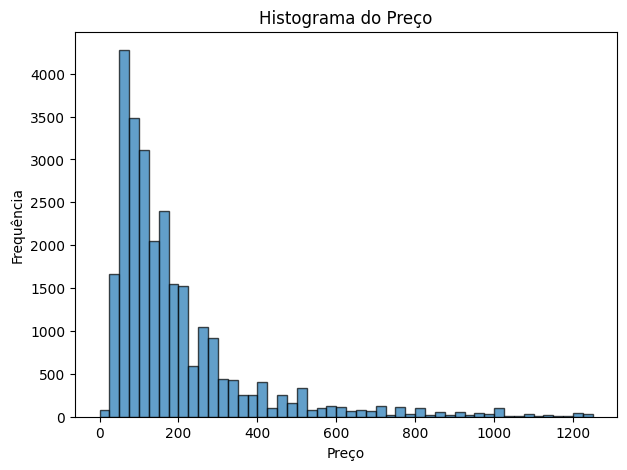

In [22]:
# Verificando se a limpeza feita anteriormente foi eficiente em eliminar possíveis distorções
df.describe()

# Criando um histograma para analisar a variável price
preco_limite = df['price'].quantile(0.99)
df_filtrado = df[df['price'] <= preco_limite]

plt.figure(figsize=(7,5))
plt.hist(df_filtrado['price'],bins=50,density=False,edgecolor='black',alpha=0.7)
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.title('Histograma do Preço')
plt.show()

# Notamos que a maior quantidade de hoteis possui preço na faixa de 0 a 200 dólares

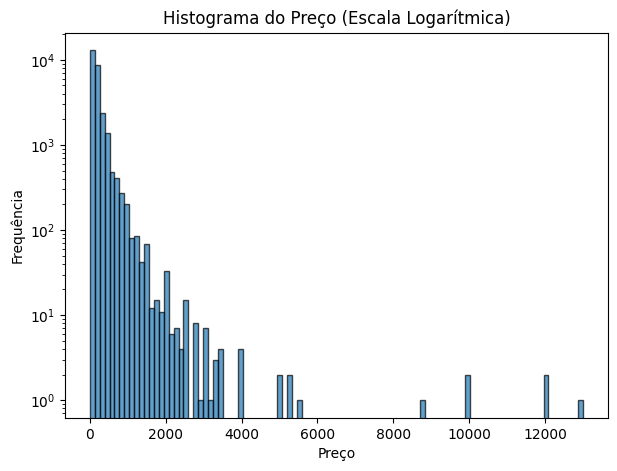

In [23]:
# Analisando o preço através da escala logaritmica

plt.figure(figsize=(7,5))
plt.hist(df['price'], bins=100,edgecolor='black',alpha=0.7)
plt.yscale('log')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.title('Histograma do Preço (Escala Logarítmica)')
plt.show()

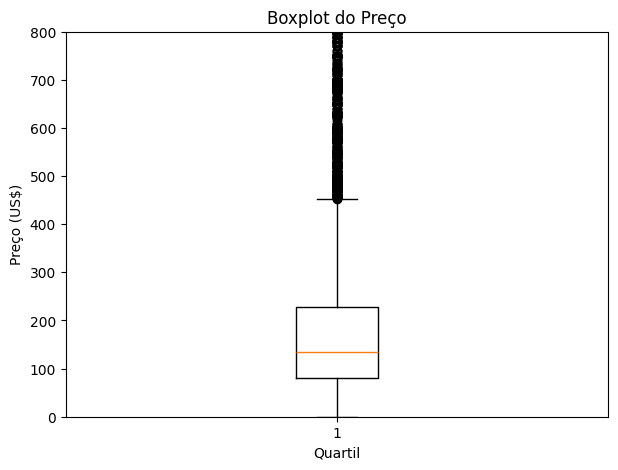

In [24]:
# Visualização do preço através de um boxplot

# Devido a forte presença de outliers, para melhorar a visualização da caixa do boxplot
# optei por limitar o eixo y em 800 US$ ( Em 1500US$ e 1000US$ a visualização continuava prejudicada)
plt.figure(figsize=(7,5))
plt.boxplot(df['price'])
plt.ylabel('Preço (US$)')
plt.xlabel('Quartil')
plt.title('Boxplot do Preço')
plt.ylim(0,800)
plt.show()

(0.0, 700.0)

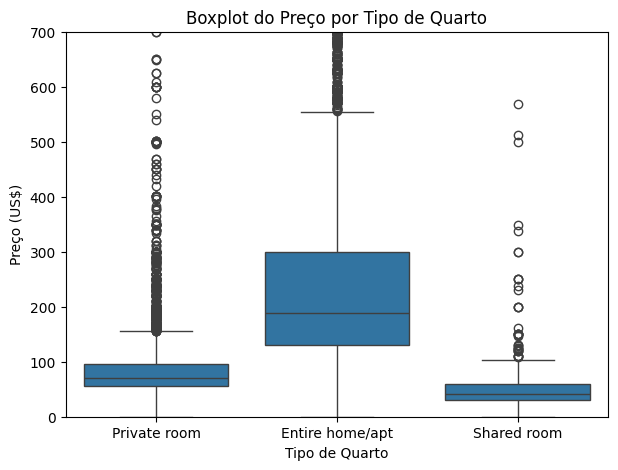

In [25]:
# Analise do preço com base no tipo de quarto

# Novamente precisei limitar o eixo y para facilitar a caixa principal do boxplot
plt.figure(figsize=(7,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.ylabel('Preço (US$)')
plt.xlabel('Tipo de Quarto')
plt.title('Boxplot do Preço por Tipo de Quarto')
plt.ylim(0,700)

# Notamos que a mediana dos apartamentos interiros é praticamente duas vezes maior que
# quartos compartilhados ou quartos privados. Os shared rooms são uma melhor opção financeira
# que os outros dois tipos e apresenta bem menos outliers.

(0.0, 700.0)

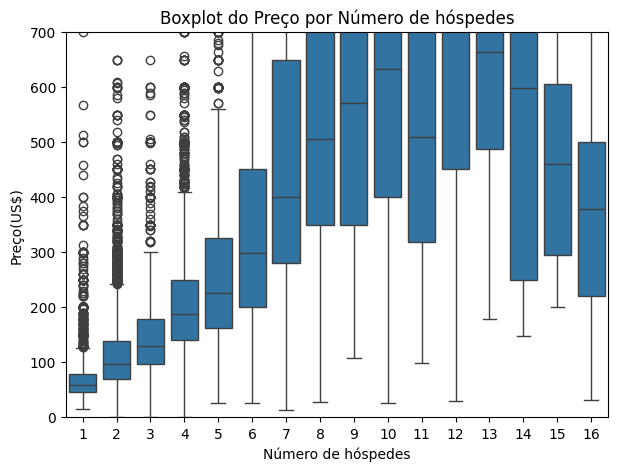

In [26]:
# Analise do preço e do número de hospedes

plt.figure(figsize=(7,5))
sns.boxplot(x='accommodates',y='price',data=df)
plt.ylabel('Preço(US$)')
plt.xlabel('Número de hóspedes')
plt.title('Boxplot do Preço por Número de hóspedes')
plt.ylim(0,700)

# Nota-se que conforme a quantidade de hóspedes cresce sua mediana de preços também cresce

(0.0, 700.0)

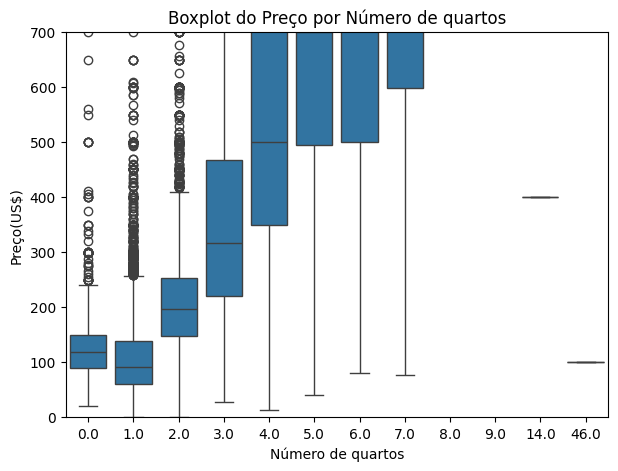

In [27]:
# Analise do preço e do número de quartos

plt.figure(figsize=(7,5))
sns.boxplot(x='bedrooms',y='price',data=df)
plt.ylabel('Preço(US$)')
plt.xlabel('Número de quartos')
plt.title('Boxplot do Preço por Número de quartos')
plt.ylim(0,700)

# Com essa análise encontrei imóveis com muitos quartos alugados a valores baixos
# Filtraremos valores granes de quartos

In [28]:
df = df[df['bedrooms']<10]

# Dessa forma os dados estão mais coesos

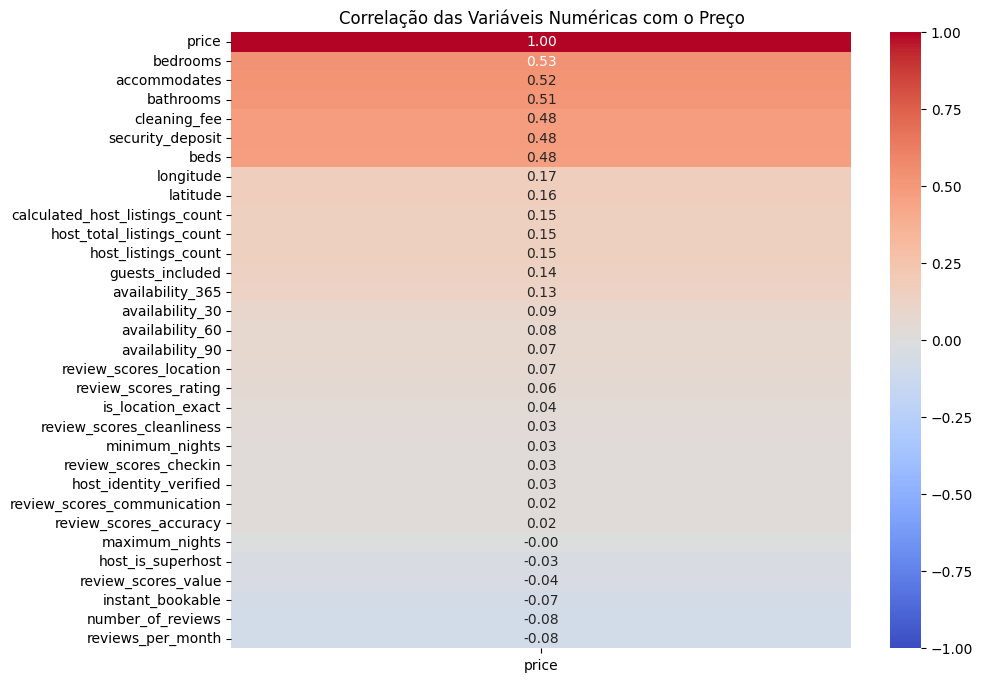

In [29]:
# Heatmap para encontrar as correlações entre as variáveis númericas e o preço

correlacao = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlacao[['price']].sort_values(by = 'price',ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlação das Variáveis Numéricas com o Preço')
plt.show()

Parte 5: Engenharia de atributos

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27060 entries, 0 to 27069
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   host_response_time                13397 non-null  object 
 1   host_response_rate                13397 non-null  object 
 2   host_is_superhost                 27025 non-null  float64
 3   host_listings_count               27025 non-null  float64
 4   host_total_listings_count         27025 non-null  float64
 5   host_identity_verified            27025 non-null  float64
 6   neighbourhood                     23006 non-null  object 
 7   neighbourhood_cleansed            27060 non-null  object 
 8   city                              27027 non-null  object 
 9   market                            26988 non-null  object 
 10  latitude                          27060 non-null  float64
 11  longitude                         27060 non-null  float64
 12  is_locati

In [37]:
# Como ja exclui algumas colunas na parte 2, vou me atentar em melhoras as colunas existentes

data_atual = pd.to_datetime('2026-09-26')
# Mais facil analisar um número(anos) do que uma data
if 'host_since' in df.columns:
  df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
  df['host_years_active'] = (data_atual - df['host_since']).dt.days / 365
  df = df.drop(columns=['host_since'])

if 'amenities' in df.columns:
  # Verificando quantos itens de comodidade existem, pois sua correlação com os preços é alta
  df['amenities_count'] = df['amenities'].astype(str).apply(lambda x: len(x.split(',')))
  df = df.drop(columns=['amenities'])

if 'last_review' in df.columns:
  # Mesmo principio do host_since
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    df['days_since_last_review'] = (data_atual - df['last_review']).dt.days.fillna(999)
    df = df.drop(columns=['first_review', 'last_review'], errors='ignore')

if 'host_response_rate' in df.columns:
    # transformando em um decimal
    df['host_response_rate'] = df['host_response_rate'].str.rstrip('%').astype(float) / 100

if 'property_type' in df.columns:
    # Mantém apenas os 5 tipos mais comuns e transforma o resto em 'Other'
    top_properties = df['property_type'].value_counts().nlargest(5).index
    df['property_type'] = df['property_type'].apply(lambda x: x if x in top_properties else 'Other')

In [41]:
# Transformando essas colunas em binárias
df['require_guest_phone_verification'] = df['require_guest_phone_verification'].map({'t':1,'f':0,True:1,False:0})
df['has_availability'] = df['has_availability'].map({'t':1,'f':0,True:1,False:0})

In [42]:
# Eliminação de colunas redundantes
df = df.drop(columns = ['neighbourhood','city','market'])

In [46]:
# Preenchimento de valores vazios com a mediana, para evitar muitas distorções
colunas_contagem = ['beds', 'bathrooms', 'bedrooms', 'host_is_superhost', 'security_deposit', 'cleaning_fee']
for col in colunas_contagem:
    if col in df.columns:
        mediana_val = df[col].median()
        df[col] = df[col].fillna(mediana_val)

# Preenchimento com zero
colunas_reviews = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month'
]

for col in colunas_reviews:
  if col in df.columns:
    # Imoveis novos podem não ter recebido avaliação e se fossem simplesmente preenchidos com zero
    # o modelo poderia entender que as notas sao ruins
    df[col + 'missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(0)


print('Tratamento de valores')
print(f"Valores nulos restantes no DataFrame: {df.isna().sum().sum()}")

Tratamento de valores
Valores nulos restantes no DataFrame: 13803


In [47]:
#preenchimento de valores ausentes no tipo object
colunas_categoricas = df.select_dtypes(include=['object']).columns
for col in colunas_categoricas:
    df[col] = df[col].fillna('Desconhecido')

In [48]:
#preenchimento de valores ausentes no tipo numero
colunas_numericas = df.select_dtypes(include=['int64','float64']).columns
for col in colunas_numericas:
    df[col] = df[col].fillna(0)

In [49]:
print('Tratamento de valores')
print(f"Valores nulos restantes no DataFrame: {df.isna().sum().sum()}")
# Não sobraram valores ausentes

Tratamento de valores
Valores nulos restantes no DataFrame: 0


Parte 4 - Divisão treino/teste estratificada

In [50]:
# Separando o que queremos prever ( df['price']) das outras colunas

# X são as features e y é o que queremos predizer
X = df.drop(columns=['price'])
y = df['price']

# Fazendo one-hot enconding em X
X = pd.get_dummies(X,drop_first=True)

# Dividindo o dataset em treino e teste
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=df['room_type'] # Variavel categorica
)

print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")

Formato dos dados de treino (X_train): (21648, 99)
Formato dos dados de teste (X_test): (5412, 99)


Parte 6: Pipeline de pré-processamento

In [52]:
from sklearn.preprocessing import StandardScaler

# padronização dos dados
scaler = StandardScaler()

# fit deve ser usado apenas no X_train
X_train_scaled = scaler.fit_transform(X_train)
# transform deve ser aplicado em X_train e X_test
X_test_scaled = scaler.transform(X_test)

print('Padronização concluida!')
print(f'Novas dimensões após padronização do X_train_scaled: {X_train_scaled.shape}')

Padronização concluida!
Novas dimensões após padronização do X_train_scaled: (21648, 99)


Parte 7: Modelos supervisionados com ajuste de hiperparâmetros

In [54]:
# Testando primeiro a regressão Linear
print(' Testando Regressão Linear')
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print(f'Regressão Linear - R2: {r2_score(y_test,y_pred_lr)}')
print(f'Regressão Linear - MAE {mean_absolute_error(y_test,y_pred_lr)}')
print(f'Regressão Linear - MSE {mean_squared_error(y_test,y_pred_lr)}')

 Testando Regressão Linear
Regressão Linear - R2: -5364.563104502718
Regressão Linear - MAE 461.7882967293147
Regressão Linear - MSE 736070371.4630286
